In [2]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.optimize import least_squares
import surfinBH
import gwsurrogate as gws
import sympy as sp
from IPython.display import display, Math
import lal
from tqdm.auto import tqdm
lal.swig_redirect_standard_output_error(True)

/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/lalsimulation/_lalsimulation_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


True

In [5]:
file_path = '/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/bbh_simulations_archive/BBH_q=0.30_chi1=0.20_chi2=0.20_th1=45_th2=45_dphi=90.csv'

In [6]:
fit = surfinBH.LoadFits('NRSur7dq4EmriRemnant')
sur_wave_precessing = gws.LoadSurrogate('NRSur7dq4')

Loaded NRSur7dq4EmriRemnant fit.
Loaded NRSur7dq4 model


### 1PN binding energy and total angular momentum

In this cell we construct the conservative orbital binding energy and the total angular momentum of a compact binary system up to 1PN order, keeping explicit powers of the speed of light $c$. The PN bookkeeping parameter is introduced as

$$
\epsilon = \frac{1}{c}.
$$

The standard dimensionless PN expansion parameter is

$$
x_{\rm PN} = \left(\frac{Gm\Omega}{c^3}\right)^{2/3},
$$

where $\Omega$ is the orbital frequency and $m=m_1+m_2$ is the total mass. In the symbolic calculation we introduce the rescaled variable $X$, defined by

$$
X = c^2 x_{\rm PN}.
$$

Equivalently,

$$
x_{\rm PN} = \frac{X}{c^2} = X\epsilon^2.
$$

This replacement is useful because it allows one to keep track explicitly of the powers of $1/c$ in the PN expansion.

The non-spinning binding energy up to 1PN order is

$$
E_{\rm bind}(X)
=

-\frac{\mu X}{2}
\left[
1+
\left(
-\frac{3}{4}


\frac{\nu}{12}
\right)
\frac{X}{c^2}
\right].
$$

The mass parameters are

$$
m = m_1+m_2,
\qquad
\mu = \frac{m_1m_2}{m},
\qquad
\nu = \frac{\mu}{m}.
$$

Here $m$ is the total mass, $\mu$ is the reduced mass, and $\nu$ is the symmetric mass ratio. The first term in $E_{\rm bind}$ is the Newtonian contribution, while the term proportional to $1/c^2$ is the 1PN point-particle correction.

The corresponding non-spinning orbital angular momentum is

$$
L_{\rm orb}(X)
=

\frac{G\mu m}{\sqrt{X}}
\left[
1+
\left(
\frac{3}{2}
+
\frac{\nu}{6}
\right)
\frac{X}{c^2}
\right].
$$

The orbital angular momentum is assumed to be aligned with the instantaneous orbital direction $\boldsymbol{\ell}$. The spins are decomposed on the orbital triad $(\mathbf n,\boldsymbol{\lambda},\boldsymbol{\ell})$ as

$$
\mathbf S_i
=

S_{in}\mathbf n
+
S_{i\lambda}\boldsymbol{\lambda}
+
S_{iL}\boldsymbol{\ell}.
$$

Therefore, the components of the total angular momentum are

$$
J_\ell
=

L_{\rm orb}
+
\frac{S_{1L}+S_{2L}}{c},
$$

$$
J_n
=

\frac{S_{1n}+S_{2n}}{c},
$$

$$
J_\lambda
=

\frac{S_{1\lambda}+S_{2\lambda}}{c}.
$$

The magnitude of the total angular momentum is

$$
J_{\rm tot}
=

\sqrt{
J_\ell^2
+
J_n^2
+
J_\lambda^2
}.
$$

Expanding $J_{\rm tot}$ in powers of $\epsilon=1/c$ separates the Newtonian orbital contribution, the leading spin contribution along $\boldsymbol{\ell}$, and the first correction induced by the transverse spin components. In this specific 1PN implementation, the binding energy is kept non-spinning. Spin-orbit corrections to the energy start at 1.5PN order, while spin-spin corrections enter at 2PN order, and are therefore not included in this cell.

**References**

* L. Blanchet, *Post-Newtonian Theory for Gravitational Waves*, Living Reviews in Relativity **17**, 2 (2014), arXiv:1310.1528.
* L. E. Kidder, *Coalescing binary systems of compact objects to post-Newtonian 5/2 order. V. Spin effects*, Physical Review D **52**, 821 (1995), arXiv:gr-qc/9506022.


In [7]:
c = sp.Symbol('c', positive=True)
eps = sp.Symbol('eps', positive=True) 
G = sp.Symbol('G', real=True, positive=True)
nu = sp.Symbol(r'\nu', real=True, positive=True)
mu = sp.Symbol(r'\mu', real=True, positive=True)
m = sp.Symbol('m', real=True, positive=True)
m1, m2 = sp.symbols('m_1 m_2', positive=True)

S1n, S2n = sp.symbols(r'S_{1n} S_{2n}', real=True)
S1lam, S2lam = sp.symbols(r'S_{1\lambda} S_{2\lambda}', real=True)
S1L, S2L = sp.symbols(r'S_{1L} S_{2L}', real=True)
x_sym = sp.Symbol('X', real=True, positive=True)
x_val = x_sym * eps**2

c1_e = -sp.Rational(3, 4) - nu/12
E_NS = -( mu * (1/eps)**2 * x_val / 2) * (1 + c1_e * x_val)
c1_j = sp.Rational(3, 2) + nu/6
L_NS = (G * mu * m / ((1/eps) * sp.sqrt(x_val))) * (1 + c1_j * x_val)
E_1PN_NS = sp.expand(E_NS)
L_1PN_NS = sp.expand(L_NS)

E_tot = E_1PN_NS
L_ell_tot = L_1PN_NS
L_n_tot = 0
L_lam_tot = 0
J_ell = L_ell_tot + eps * (S1L + S2L)
J_n = L_n_tot + eps * (S1n + S2n)
J_lam = L_lam_tot + eps * (S1lam + S2lam)
J_tot = sp.sqrt(J_ell**2+ J_n**2 + J_lam**2)
E_tot_eps = sp.series(E_tot, eps, 0, 3).removeO()
J_tot_eps = sp.series(J_tot, eps, 0, 3).removeO()

def get_eps_terms(expr, max_power=2):
    
    expr = sp.expand(expr)
    terms = {}
    for power in range(max_power + 1):
        coeff = sp.expand(expr).coeff(eps, power)

        if coeff != 0:
            terms[power] = sp.simplify(coeff)
    return terms

def pn_label_from_eps_power(power):
    
    labels = {
        0: r"\mathrm{N}",
        1: r"S/c",
        2: r"1\mathrm{PN}",
    }
    return labels.get(power, rf"\epsilon^{power}")

def display_pn_terms(name, expr_eps, max_power=2):
    
    terms = get_eps_terms(expr_eps, max_power=max_power)
    lines = []
    total_terms = []
    for power, coeff in terms.items():

        term_with_c = coeff / c**power
        total_terms.append(term_with_c)

        label = pn_label_from_eps_power(power)

        lines.append(
            rf"{name}_{{{label}}} &= {sp.latex(term_with_c)}"
        )
    total_expr = sp.Add(*total_terms, evaluate=False)
    lines.append(
        rf"{name} &= {sp.latex(total_expr)}"
    )
    latex_str = r"\begin{aligned}" + r"\\".join(lines) + r"\end{aligned}"
    display(Math(latex_str))
    print("\n" + "-"*80 + "\n")

print(r"1. Total binding energy up to 1PN:" + "\n")
display_pn_terms(r"E_{\rm bind}^{1PN}(X)", E_tot_eps, max_power=2)
print(r"2. Total angular momentum up to 1PN:" + "\n")
display_pn_terms(r"J_{\rm tot}^{1PN}(X)", J_tot_eps, max_power=2)

1. Total binding energy up to 1PN:



<IPython.core.display.Math object>


--------------------------------------------------------------------------------

2. Total angular momentum up to 1PN:



<IPython.core.display.Math object>


--------------------------------------------------------------------------------



In [8]:
def entropy(M, J):
    M = np.asarray(M)
    J = np.asarray(J)
    arg_sqrt = M**2 - ((J**2)/(M**2))
    arg_sqrt = np.where(arg_sqrt < 0, np.nan, arg_sqrt)
    S = 2 * np.pi * M * (M + np.sqrt(arg_sqrt))
    
    return S

In [9]:
def get_1PN_precessing(
    a_prec,
    th1,
    th2,
    dphi,
    chi1,
    chi2,
    m1,
    m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
):
    
    def to_float_scalar(value, name):
        try:
            return float(value)
        except Exception as exc:
            raise TypeError(
                f"{name} must be a float, but {value!r} was given. "
            ) from exc

    chi1 = to_float_scalar(chi1, "chi1")
    chi2 = to_float_scalar(chi2, "chi2")
    m1 = to_float_scalar(m1, "m1")
    m2 = to_float_scalar(m2, "m2")
    c = to_float_scalar(c, "c")
    G = to_float_scalar(G, "G")

    a_prec = np.asarray(a_prec, dtype=float)
    th1 = np.asarray(th1, dtype=float)
    th2 = np.asarray(th2, dtype=float)
    dphi = np.asarray(dphi, dtype=float)

    a_prec, th1, th2, dphi = np.broadcast_arrays(a_prec,th1,th2,dphi)

    m = m1 + m2
    mu = m1 * m2 / m
    nu = mu / m

    if separation_is_dimensionless:
        Gamma = G / a_prec
    else:
        Gamma = G * m / a_prec

    E_bind_0PN = -0.5 * mu * Gamma
    E_bind_1PN = mu * Gamma**2 * (7.0 - nu) / 8.0

    E_bind = E_bind_0PN + E_bind_1PN / c**2

    E_tot = m + E_bind / c**2

    L_orb_0PN = G * mu * m / np.sqrt(Gamma)
    L_orb_1PN = 2.0 * G * mu * m * np.sqrt(Gamma)

    L_orb = L_orb_0PN + L_orb_1PN / c**2

    L_vec = np.column_stack([np.zeros_like(L_orb),np.zeros_like(L_orb),L_orb])

    S1_mag = G * chi1 * m1**2
    S2_mag = G * chi2 * m2**2

    S1_vec = S1_mag * np.column_stack([np.sin(th1),np.zeros_like(th1),np.cos(th1)])
    S2_vec = S2_mag * np.column_stack([np.sin(th2) * np.cos(dphi),np.sin(th2) * np.sin(dphi),np.cos(th2)])

    J_vec = L_vec + (S1_vec + S2_vec) / c
    J_tot = np.sqrt(np.sum(J_vec**2, axis=1))

    return {
        "Gamma": Gamma,
        "nu": nu,
        "mu": mu,
        "m": m,
        "E_bind": E_bind,
        "E_tot": E_tot,
        "L_orb": L_orb,
        "L_vec": L_vec,
        "S1_vec": S1_vec,
        "S2_vec": S2_vec,
        "J_vec": J_vec,
        "J_tot": J_tot
    }

In [10]:
def get_merger_separation_NR(q_prec, chi1_0_vec, chi2_0_vec, f_low=0.01):

    q_prec = float(q_prec)
    chi1_0_vec = np.asarray(chi1_0_vec, dtype=float).flatten()
    chi2_0_vec = np.asarray(chi2_0_vec, dtype=float).flatten()

    if chi1_0_vec.shape != (3,):
        raise ValueError(f"chi1_0_vec must have shape (3,), got {chi1_0_vec.shape}.")
    if chi2_0_vec.shape != (3,):
        raise ValueError(f"chi2_0_vec must have shape (3,), got {chi2_0_vec.shape}.")
    if q_prec <= 0:
        raise ValueError("q_prec must be positive.")
    if q_prec <= 1.0:
        q_surr = 1.0 / q_prec
        chi_surr_1 = chi1_0_vec
        chi_surr_2 = chi2_0_vec
    else:
        q_surr = q_prec
        chi_surr_1 = chi1_0_vec
        chi_surr_2 = chi2_0_vec

    t, h, _ = sur_wave_precessing(q_surr,chi_surr_1,chi_surr_2,dt=0.1,f_low=f_low)
    amp_tot_sq = np.zeros_like(t, dtype=float)
    omega_orb_num = np.zeros_like(t, dtype=float)
    omega_orb_den = np.zeros_like(t, dtype=float)

    for mode, h_lm in h.items():

        ell, m = mode
        h_lm = np.asarray(h_lm, dtype=complex)
        amp_lm_sq = np.abs(h_lm)**2
        amp_tot_sq += amp_lm_sq
        if m == 0:
            continue
        phase_lm = np.unwrap(np.angle(h_lm))
        omega_lm = np.abs(np.gradient(phase_lm, t))
        omega_orb_lm = omega_lm / abs(m)
        omega_orb_num += amp_lm_sq * omega_orb_lm
        omega_orb_den += amp_lm_sq

    A_tot = np.sqrt(amp_tot_sq)
    omega_orb = np.full_like(t, np.nan, dtype=float)
    mask_omega = omega_orb_den > 0.0
    omega_orb[mask_omega] = omega_orb_num[mask_omega] / omega_orb_den[mask_omega]
    r_inst = np.full_like(t, np.nan, dtype=float)
    mask_r = np.isfinite(omega_orb) & (omega_orb > 0.0)
    r_inst[mask_r] = omega_orb[mask_r]**(-2.0 / 3.0)
    idx_merger = np.argmax(A_tot)
    r_merger = r_inst[idx_merger]

    if not np.isfinite(r_merger):
        finite_idx = np.where(np.isfinite(r_inst))[0]
        if len(finite_idx) == 0:
            raise RuntimeError("No finite effective separation could be computed.")
        nearest = finite_idx[np.argmin(np.abs(finite_idx - idx_merger))]
        r_merger = r_inst[nearest]

    return r_merger, t, r_inst

In [11]:
def pade_2_1(x, a0, a1, a2, b1):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x)
def pade_1_2(x, a0, a1, b1, b2):
    return (a0 + a1*x) / (1 + b1*x + b2*x**2)
def pade_2_2(x, a0, a1, a2, b1, b2):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x + b2*x**2)
def pade_3_1(x, a0, a1, a2, a3, b1):
    return (a0 + a1*x + a2*x**2 + a3*x**3) / (1 + b1*x)

In [12]:
with open(file_path, 'r') as f:
    f.readline()
    header_line = f.readline()

q_prec = float(re.search(r'q=([\d.]+)', header_line).group(1))
chi1 = float(re.search(r'chi1=([\d.]+)', header_line).group(1))
chi2 = float(re.search(r'chi2=([\d.]+)', header_line).group(1))
theta1_0_deg = float(re.search(r'theta1_0_deg=([\d.]+)', header_line).group(1))
theta2_0_deg = float(re.search(r'theta2_0_deg=([\d.]+)', header_line).group(1))
deltaphi_0_deg = float(re.search(r'deltaphi_0_deg=([\d.]+)', header_line).group(1))

theta1_0_rad = np.radians(theta1_0_deg)
theta2_0_rad = np.radians(theta2_0_deg)
phi1_0_rad = 0
phi2_0_rad = np.radians(deltaphi_0_deg)

df = pd.read_csv(file_path, comment='#')
a_prec = df['separation_M'].to_numpy()
th1 = df['theta1_rad'].to_numpy()
th2 = df['theta2_rad'].to_numpy()
dphi = df['deltaphi_rad'].to_numpy()

chi1_0_x = chi1 * np.sin(theta1_0_rad) * np.cos(phi1_0_rad)
chi1_0_y = chi1 * np.sin(theta1_0_rad) * np.sin(phi1_0_rad)
chi1_0_z = chi1 * np.cos(theta1_0_rad)
chi1_0_vec = np.array([chi1_0_x, chi1_0_y, chi1_0_z])

chi2_0_x = chi2 * np.sin(theta2_0_rad) * np.cos(phi2_0_rad)
chi2_0_y = chi2 * np.sin(theta2_0_rad) * np.sin(phi2_0_rad)
chi2_0_z = chi2 * np.cos(theta2_0_rad)
chi2_0_vec = np.array([chi2_0_x, chi2_0_y, chi2_0_z])

chi1_x = chi1 * np.sin(th1)
chi1_y = np.zeros_like(th1)
chi1_z = chi1 * np.cos(th1)
chi1_vec = np.array([chi1_x, chi1_y, chi1_z])

chi2_x = chi2 * np.sin(th2) * np.cos(dphi)
chi2_y = chi2 * np.sin(th2) * np.sin(dphi)
chi2_z = chi2 * np.cos(th2)
chi2_vec = np.array([chi2_x, chi2_y, chi2_z])

m1 = 1.0 / (1.0 + q_prec)
m2 = q_prec / (1.0 + q_prec)

In [13]:
# surrogate prediction
q_surr = 1.0 / q_prec
mf_surr, chif_surr, vf_surr, mf_err_surr, chif_err_surr, vf_err_surr = fit.all(q_surr, chi1_0_vec, chi2_0_vec)
chif_mag = np.linalg.norm(chif_surr)
Jf_surr = chif_mag * mf_surr**2
ent_surr = entropy(mf_surr, Jf_surr)
a_merger, t_surr, a_inst = get_merger_separation_NR(q_surr, chi1_0_vec, chi2_0_vec, f_low=0.01)
print("NR Merger a =", a_merger)
print("Surrogate Entropy =", ent_surr)

NR Merger a = 3.133805714402399
Surrogate Entropy = 10.70668988037251


In [14]:
m1_num = 1.0 / (1.0 + q_prec)
m2_num = q_prec / (1.0 + q_prec)

out_1PN = get_1PN_precessing(
    a_prec=a_prec,
    th1=th1,
    th2=th2,
    dphi=dphi,
    chi1=chi1,
    chi2=chi2,
    m1=m1_num,
    m2=m2_num,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
)

E_tot_1PN = out_1PN["E_tot"]
E_bind_1PN = out_1PN["E_bind"]
J_tot_1PN = out_1PN["J_tot"]
J_vec_1PN = out_1PN["J_vec"]
L_orb_1PN = out_1PN["L_orb"]

ENT = entropy(E_tot_1PN,J_tot_1PN)

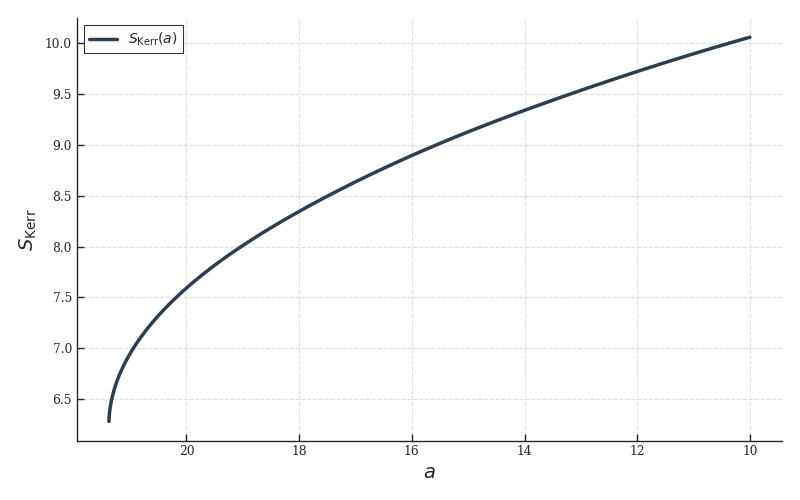

In [15]:
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,        
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in"      
})

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.plot(a_prec, ENT, label=r"$S_{\rm Kerr}(a)$", color="#2c3e50", lw=2.5, zorder=2)
ax.invert_xaxis()
ax.set_xlabel(r"$a\ $") 
ax.set_ylabel(r"$S_{\rm Kerr}\ $") 
ax.legend(frameon=True, shadow=False, fancybox=False, edgecolor="black", loc='best')
sns.despine()
plt.tight_layout()
plt.show()

### Padé $[2/1]$ extrapolation of the 1PN entropy curve

In this cell we extrapolate the 1PN entropy curve toward smaller separations using a Padé $[2/1]$ approximant. Starting from the valid 1PN data, we first select only physical points satisfying

$$
a>0,
\qquad
M_{\rm tot}>0,
\qquad
|\chi|\leq 1.
$$

The fitting variable is chosen as

$$
x = \frac{1}{\sqrt{a}},
$$

which increases as the binary separation decreases. Instead of fitting the entropy directly, we fit separately the binding energy

$$
E_{\rm bind}=M_{\rm tot}-m
$$

and the dimensionless Kerr spin parameter

$$
\chi = \frac{J_{\rm tot}}{M_{\rm tot}^2}.
$$

Both quantities are fitted with a Padé $[2/1]$ model,

$$
P_{[2/1]}(x)
=

\frac{a_0+a_1x+a_2x^2}{1+b_1x}.
$$

The fit is performed with a least-squares routine using a `soft_l1` loss. Several initial guesses are tested through a multi-start procedure, and the solution with the smallest cost is retained. The weights are chosen as

$$
\sigma(a)=\left(\frac{a}{a_{\min}}\right),
$$

so that points at smaller separation have larger statistical weight in the fit.

After the extrapolation, the total mass and angular momentum are reconstructed as

$$
M_{\rm extrap}=m+E_{\rm bind}^{\rm extrap},
$$

$$
J_{\rm extrap}
=

\chi_{\rm extrap}
M_{\rm extrap}^2.
$$

The Kerr entropy is then computed from the reconstructed quantities,

$$
S_{\rm Kerr}
=

2\pi M
\left(
M+
\sqrt{
M^2-\frac{J^2}{M^2}
}
\right).
$$

Only physical extrapolated points with $M>0$ and $|\chi|\leq1$ are retained. The maximum of the extrapolated entropy curve defines

$$
a_{\max}^{\rm Padé},
$$

which is then compared with the merger separation predicted by the surrogate model,

$$
a_{\rm merger}^{\rm NR}.
$$

The main diagnostic quantity is therefore

$$
\Delta a
=

\left|
a_{\max}^{\rm Padé}
-

a_{\rm merger}^{\rm NR}
\right|.
$$

This provides a direct test of whether the maximum of the extrapolated entropy curve occurs close to the surrogate merger separation.


In [16]:
valid_mask_P = (np.isfinite(ENT)& np.isfinite(a_prec)& np.isfinite(E_tot_1PN)& np.isfinite(J_tot_1PN)& (a_prec > 0)& (E_tot_1PN > 0))
a_valid_P = a_prec[valid_mask_P]
M_valid_P = E_tot_1PN[valid_mask_P]
J_valid_P = J_tot_1PN[valid_mask_P]
S_valid_P = ENT[valid_mask_P]
sort_idx_P = np.argsort(a_valid_P)
a_fit_P = a_valid_P[sort_idx_P]
M_fit_P = M_valid_P[sort_idx_P]
J_fit_P = J_valid_P[sort_idx_P]
S_fit_P = S_valid_P[sort_idx_P]
x_fit_P = 1.0 / np.sqrt(a_fit_P)

try:
    m_ref_P = float(m1_num + m2_num)
except NameError:
    m_ref_P = 1.0

Ebind_fit_P = M_fit_P - m_ref_P
chi_fit_P = J_fit_P / M_fit_P**2
fit_mask_P = (np.isfinite(x_fit_P)& np.isfinite(Ebind_fit_P)& np.isfinite(chi_fit_P)& (np.abs(chi_fit_P) <= 1.0))
a_fit_P = a_fit_P[fit_mask_P]
x_fit_P = x_fit_P[fit_mask_P]
M_fit_P = M_fit_P[fit_mask_P]
J_fit_P = J_fit_P[fit_mask_P]
S_fit_P = S_fit_P[fit_mask_P]
Ebind_fit_P = Ebind_fit_P[fit_mask_P]
chi_fit_P = chi_fit_P[fit_mask_P]

a_min_fit_P = np.nanmin(a_fit_P)
sigma_fit_P = (a_fit_P / a_min_fit_P)**1.0


def pade_2_1_fit_P(
    x_P,
    y_P,
    sigma_P,
    y_scale_P=None,
    n_starts_P=60,
    random_seed_P=1234,
    loss_P="soft_l1",
    f_scale_P=1.0,
    max_nfev_P=50000,
    progress_label_P="Padé [2/1] fit"
):
    
    x_P = np.asarray(x_P, dtype=float)
    y_P = np.asarray(y_P, dtype=float)
    sigma_P = np.asarray(sigma_P, dtype=float)
    valid_P = (np.isfinite(x_P)& np.isfinite(y_P)& np.isfinite(sigma_P)& (sigma_P > 0))
    x_P = x_P[valid_P]
    y_P = y_P[valid_P]
    sigma_P = sigma_P[valid_P]
    lower_bounds_P = np.array([-np.inf, -np.inf, -np.inf, 0.0], dtype=float)
    upper_bounds_P = np.array([ np.inf,  np.inf,  np.inf, np.inf], dtype=float)
    def residuals_P(params_P):
        y_model_P = pade_2_1(x_P, *params_P)
        res_P = (y_model_P - y_P) / sigma_P
        res_P = np.where(np.isfinite(res_P), res_P, 1.0e12)
        return res_P
    rng_P = np.random.default_rng(random_seed_P)
    starts_P = []
    starts_P.append(np.array([np.nanmedian(y_P),0.0,0.0,0.1],dtype=float))
    for _P in range(n_starts_P - 1):
        starts_P.append(np.array([np.nanmedian(y_P),rng_P.normal(loc=0.0, scale=0.2 * y_scale_P),rng_P.normal(loc=0.0, scale=0.2 * y_scale_P),rng_P.uniform(low=0.0, high=1.0)],dtype=float))
    best_result_P = None
    best_cost_P = np.inf
    last_exception_P = None
    iterator_P = tqdm(starts_P,desc=progress_label_P,total=len(starts_P),leave=True)

    for p0_P in iterator_P:
        try:
            res_P = least_squares(
                residuals_P,
                p0_P,
                bounds=(lower_bounds_P, upper_bounds_P),
                loss=loss_P,
                f_scale=f_scale_P,
                x_scale="jac",
                max_nfev=max_nfev_P
            )
            if res_P.success and np.isfinite(res_P.cost) and res_P.cost < best_cost_P:
                best_result_P = res_P
                best_cost_P = res_P.cost
            iterator_P.set_postfix(best_cost=f"{best_cost_P:.3e}")
        except Exception as exc_P:
            last_exception_P = exc_P
            iterator_P.set_postfix(error=str(exc_P)[:40])
            continue
    if best_result_P is None:
        raise RuntimeError(
            "Fit robusto fallito per Padé [2/1].\n"
            f"Ultima eccezione intercettata: {repr(last_exception_P)}"
        )
    return best_result_P.x, best_result_P

model_name_P = "Padé [2/1]"

N_STARTS_EBIND_P = 10
N_STARTS_CHI_P = 10

popt_Ebind_P, result_Ebind_P = pade_2_1_fit_P(
    x_P=x_fit_P,
    y_P=Ebind_fit_P,
    sigma_P=sigma_fit_P,
    y_scale_P=np.nanstd(Ebind_fit_P),
    n_starts_P=N_STARTS_EBIND_P,
    random_seed_P=1234,
    loss_P="soft_l1",
    f_scale_P=1.0,
    max_nfev_P=30000,
    progress_label_P=r"Fitting E_bind with Padé [2/1]"
)

popt_chi_P, result_chi_P = pade_2_1_fit_P(
    x_P=x_fit_P,
    y_P=chi_fit_P,
    sigma_P=sigma_fit_P,
    y_scale_P=np.nanstd(chi_fit_P),
    n_starts_P=N_STARTS_CHI_P,
    random_seed_P=4321,
    loss_P="soft_l1",
    f_scale_P=1.0,
    max_nfev_P=15000,
    progress_label_P=r"Fitting chi with Padé [2/1]"
)

a_extrap_P = np.linspace(15.0, 1.0, 10000)
x_extrap_P = 1.0 / np.sqrt(a_extrap_P)
Ebind_extrap_P = pade_2_1(x_extrap_P, *popt_Ebind_P)
chi_extrap_P = pade_2_1(x_extrap_P, *popt_chi_P)
M_extrap_P = m_ref_P + Ebind_extrap_P
J_extrap_P = chi_extrap_P * M_extrap_P**2

physical_mask_P = (np.isfinite(M_extrap_P)& np.isfinite(chi_extrap_P)& np.isfinite(J_extrap_P)& (M_extrap_P > 0)& (np.abs(chi_extrap_P) <= 1.0))
ENT_extrap_P = np.full_like(a_extrap_P, np.nan, dtype=float)
ENT_extrap_P[physical_mask_P] = entropy(M_extrap_P[physical_mask_P],J_extrap_P[physical_mask_P])

if np.all(np.isnan(ENT_extrap_P)):
    raise RuntimeError(
        "La curva Padé [2/1] estrapolata non contiene punti fisici validi."
    )

idx_max_P = np.nanargmax(ENT_extrap_P)
a_max_entropy_P = a_extrap_P[idx_max_P]
S_max_entropy_P = ENT_extrap_P[idx_max_P]
M_at_max_P = M_extrap_P[idx_max_P]
J_at_max_P = J_extrap_P[idx_max_P]
chi_at_max_P = chi_extrap_P[idx_max_P]
delta_a_P = np.abs(a_max_entropy_P - a_merger)
accepted_results_P = [
    {
        "model": model_name_P,
        "a_max": a_max_entropy_P,
        "S_max": S_max_entropy_P,
        "M_at_max": M_at_max_P,
        "J_at_max": J_at_max_P,
        "chi_at_max": chi_at_max_P,
        "delta_a": delta_a_P,
        "cost_Ebind": result_Ebind_P.cost,
        "cost_chi": result_chi_P.cost,
        "nfev_Ebind": result_Ebind_P.nfev,
        "nfev_chi": result_chi_P.nfev
    }
]

results_df_P = pd.DataFrame(accepted_results_P)
pade_curves_P = {
    model_name_P: {
        "a_extrap": a_extrap_P,
        "x_extrap": x_extrap_P,
        "Ebind_extrap": Ebind_extrap_P,
        "M_extrap": M_extrap_P,
        "J_extrap": J_extrap_P,
        "chi_extrap": chi_extrap_P,
        "ENT_extrap": ENT_extrap_P,
        "popt_Ebind": popt_Ebind_P,
        "popt_chi": popt_chi_P,
        "result_Ebind": result_Ebind_P,
        "result_chi": result_chi_P,
        "physical_mask": physical_mask_P
    }
}

print("============================================================")
print("PADÉ [2/1] FIT ON E_bind AND chi")
print("============================================================")
print(f"Maximum with Padé [2/1] at a = {a_max_entropy_P:.6f}")
print(f"NR Merger a                   = {a_merger:.6f}")
print(f"Delta a                       = {delta_a_P:.6f}")
print("============================================================")

Fitting E_bind with Padé [2/1]:   0%|          | 0/10 [00:00<?, ?it/s]

Fitting chi with Padé [2/1]:   0%|          | 0/10 [00:00<?, ?it/s]

PADÉ [2/1] FIT ON E_bind AND chi
Maximum with Padé [2/1] at a = 3.139414
NR Merger a                   = 3.133806
Delta a                       = 0.005608


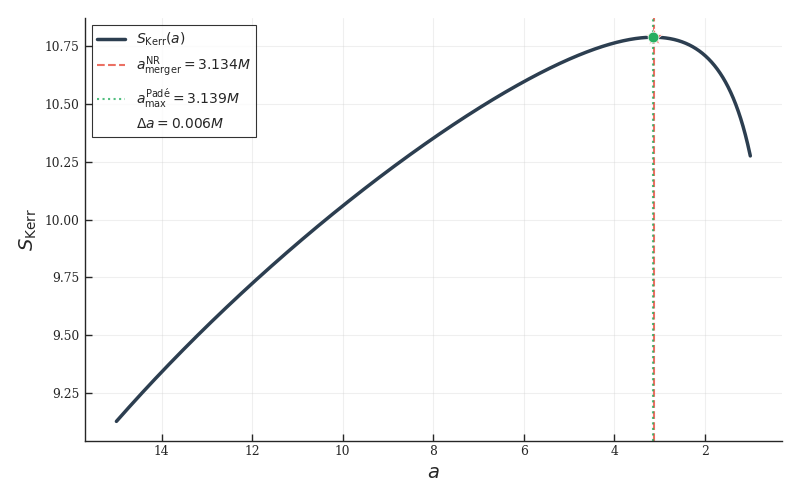

In [17]:
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

sort_idx_P = np.argsort(a_extrap_P)
a_sorted_P = a_extrap_P[sort_idx_P]
ent_sorted_P = ENT_extrap_P[sort_idx_P]
valid_interp_mask_P = (np.isfinite(a_sorted_P)&np.isfinite(ent_sorted_P))
a_sorted_valid_P = a_sorted_P[valid_interp_mask_P]
ent_sorted_valid_P = ent_sorted_P[valid_interp_mask_P]
y_at_merger_P = np.interp(a_merger,a_sorted_valid_P,ent_sorted_valid_P)
y_at_max_entropy_P = np.interp(a_max_entropy_P,a_sorted_valid_P,ent_sorted_valid_P)
delta_a_P = np.abs(a_max_entropy_P - a_merger)

fig_P, ax_P = plt.subplots(figsize=(8, 5))
ax_P.plot(a_extrap_P,ENT_extrap_P,label=r"$S_{\rm Kerr}(a)$",color="#2c3e50",lw=2.5)
ax_P.scatter(a_merger,y_at_merger_P,marker="*",s=150,color="#e74c3c",zorder=5,edgecolor="white",linewidth=0.5)
ax_P.scatter(a_max_entropy_P,y_at_max_entropy_P,marker="o",s=60,color="#27ae60",zorder=5,edgecolor="white",linewidth=0.5)
ax_P.axvline(a_merger,color="#e74c3c",linestyle="--",lw=1.5,alpha=0.8,label=fr"$a_{{\rm merger}}^{{\rm NR}}={a_merger:.3f}M$")
ax_P.axvline(a_max_entropy_P,color="#27ae60",linestyle=":",lw=1.5,alpha=0.8,label=fr"$a_{{\max}}^{{\rm Pad\acute{{e}}}}={a_max_entropy_P:.3f}M$")
ax_P.plot([],[]," ",label=fr"$\Delta a={delta_a_P:.3f}M$")
ax_P.invert_xaxis()
ax_P.set_xlabel(r"$a$")
ax_P.set_ylabel(r"$S_{\rm Kerr}$")
ax_P.legend(frameon=True,shadow=False,fancybox=False,edgecolor="black",loc="best")
sns.despine()
plt.tight_layout()
plt.show()

### Taylor extrapolation of the 1PN entropy curve

In this cell we extrapolate the 1PN entropy curve toward smaller separations using a Taylor polynomial model. Starting from the valid 1PN data, we first select only finite and physical points satisfying

$$
a>0,
\qquad
M_{\rm tot}^{\rm 1PN}>0.
$$

The corresponding arrays for the separation, total mass, total angular momentum and entropy are then defined as

$$
a,
\qquad
M_{\rm tot}^{\rm 1PN},
\qquad
J_{\rm tot}^{\rm 1PN},
\qquad
S_{\rm Kerr}^{\rm 1PN}.
$$

The data are sorted with respect to the binary separation $a$, and the fitting variable is chosen as

$$
x=
\frac{1}{\sqrt{a}},
$$

which increases as the binary separation decreases.

As in the Padé extrapolation, the entropy is not fitted directly. Instead, we fit separately the 1PN binding energy

$$
E_{\rm bind}^{\rm 1PN}
=

M_{\rm tot}^{\rm 1PN}-m,
$$

and the dimensionless Kerr spin parameter

$$
\chi^{\rm 1PN}
=

\frac{J_{\rm tot}^{\rm 1PN}}
{\left(M_{\rm tot}^{\rm 1PN}\right)^2}.
$$

Only the points for which both quantities are finite and satisfy the Kerr bound

$$
|\chi^{\rm 1PN}|\leq 1
$$

are retained in the fit. A minimum number of valid points is also required in order to avoid performing an unreliable extrapolation.

The fitting weights are chosen as

$$
\sigma(a)
=

\left(
\frac{a}{a_{\min}}
\right),
$$

so that points at smaller separation have larger statistical weight in the fit.

The Taylor model is written in terms of the rescaled variable

$$
z
=

\frac{x-x_{\rm center}}{x_{\rm scale}},
$$

where

$$
x_{\rm center}
=

\langle x\rangle,
\qquad
x_{\rm scale}
=

{\rm std}(x).
$$

This rescaling improves the numerical conditioning of the polynomial fit. The fitted model has the form

$$
T_n(z)
=

c_0+c_1 z+c_2 z^2+\cdots+c_n z^n.
$$

In this implementation, both the binding energy and the Kerr spin parameter are fitted with cubic Taylor polynomials,

$$
T_3(z)
=

c_0+c_1 z+c_2 z^2+c_3 z^3.
$$

Therefore,

$$
E_{\rm bind}^{\rm 1PN}(x)
\simeq
T_3^{E_{\rm bind}}(z),
$$

and

$$
\chi^{\rm 1PN}(x)
\simeq
T_3^{\chi}(z).
$$

The fit is performed with a robust least-squares routine using a `soft_l1` loss. As an initial guess, a weighted polynomial fit is computed with weights proportional to $1/\sigma(a)$. The robust fit is then used to reduce the influence of possible outliers in the 1PN data.

After the fit, the Taylor models are evaluated on the extrapolation interval

$$
1\leq a \leq 15,
$$

with

$$
x_{\rm extrap}
=

\frac{1}{\sqrt{a_{\rm extrap}}}.
$$

The extrapolated total mass is reconstructed as

$$
M_{\rm extrap}^{\rm 1PN}
=

m+
E_{\rm bind,extrap}^{\rm 1PN},
$$

while the extrapolated angular momentum is reconstructed from the extrapolated Kerr spin parameter as

$$
J_{\rm extrap}^{\rm 1PN}
=

\chi_{\rm extrap}^{\rm 1PN}
\left(
M_{\rm extrap}^{\rm 1PN}
\right)^2.
$$

The Kerr entropy is then computed from the reconstructed quantities,

$$
S_{\rm Kerr}
=

2\pi M
\left(
M+
\sqrt{
M^2-\frac{J^2}{M^2}
}
\right).
$$

Only physical extrapolated points are retained, namely those satisfying

$$
M_{\rm extrap}^{\rm 1PN}>0,
\qquad
|\chi_{\rm extrap}^{\rm 1PN}|\leq 1,
\qquad
|J_{\rm extrap}^{\rm 1PN}|
\leq
\left(M_{\rm extrap}^{\rm 1PN}\right)^2.
$$

The maximum of the Taylor-extrapolated entropy curve defines

$$
a_{\max}^{\rm Taylor,,1PN},
$$

together with the corresponding values

$$
S_{\max}^{\rm Taylor,,1PN},
\qquad
M_{\max}^{\rm Taylor,,1PN},
\qquad
J_{\max}^{\rm Taylor,,1PN},
\qquad
\chi_{\max}^{\rm Taylor,,1PN}.
$$

This separation is then compared with the merger separation predicted by the surrogate model,

$$
a_{\rm merger}^{\rm NR}.
$$

The main diagnostic quantity is therefore

$$
\Delta a
=

\left|
a_{\max}^{\rm Taylor,,1PN}
-

a_{\rm merger}^{\rm NR}
\right|.
$$

This provides a direct test of whether the maximum of the Taylor-extrapolated 1PN entropy curve occurs close to the surrogate merger separation. Boundary checks are also performed: if the entropy maximum is located at the edge of the extrapolation interval, the peak may not be properly resolved and the extrapolation should be interpreted with caution. The fit costs and the number of function evaluations for both the binding-energy fit and the spin-parameter fit are stored as additional diagnostics of the robustness of the result.


In [19]:
valid_mask_T = (np.isfinite(ENT)& np.isfinite(a_prec)& np.isfinite(E_tot_1PN)& np.isfinite(J_tot_1PN)& (a_prec > 0)& (E_tot_1PN > 0))
a_valid_T = a_prec[valid_mask_T]
M_valid_T = E_tot_1PN[valid_mask_T]
J_valid_T = J_tot_1PN[valid_mask_T]
S_valid_T = ENT[valid_mask_T]
sort_idx_T = np.argsort(a_valid_T)
a_fit_T = a_valid_T[sort_idx_T]
M_fit_T = M_valid_T[sort_idx_T]
J_fit_T = J_valid_T[sort_idx_T]
S_fit_T = S_valid_T[sort_idx_T]
x_fit_T = 1.0 / np.sqrt(a_fit_T)

try:
    m_ref_T = float(m1_num + m2_num)
except NameError:
    m_ref_T = 1.0

Ebind_fit_T = M_fit_T - m_ref_T
chi_fit_T = J_fit_T / M_fit_T**2
fit_mask_T = (np.isfinite(x_fit_T)& np.isfinite(Ebind_fit_T)& np.isfinite(chi_fit_T)& (np.abs(chi_fit_T) <= 1.0))
a_fit_T = a_fit_T[fit_mask_T]
x_fit_T = x_fit_T[fit_mask_T]
M_fit_T = M_fit_T[fit_mask_T]
J_fit_T = J_fit_T[fit_mask_T]
S_fit_T = S_fit_T[fit_mask_T]
Ebind_fit_T = Ebind_fit_T[fit_mask_T]
chi_fit_T = chi_fit_T[fit_mask_T]

if len(x_fit_T) < 20:
    raise RuntimeError(
        f"Too few valid points for a reliable Taylor fit: {len(x_fit_T)}"
    )

a_min_fit_T = np.nanmin(a_fit_T)
sigma_fit_T = (a_fit_T / a_min_fit_T)**1.0

def taylor_model_scaled_T(x_T, coeffs_T, x_center_T, x_scale_T):
    
    x_T = np.asarray(x_T, dtype=float)
    z_T = (x_T - x_center_T) / x_scale_T
    y_T = np.zeros_like(z_T, dtype=float)
    for k_T, ck_T in enumerate(coeffs_T):
        y_T += ck_T * z_T**k_T
    return y_T

def taylor_fit_T(
    x_T,
    y_T,
    sigma_T,
    degree_T=3,
    loss_T="soft_l1",
    f_scale_T=1.0,
    max_nfev_T=50000,
    progress_label_T="Taylor fit"
):

    x_T = np.asarray(x_T, dtype=float)
    y_T = np.asarray(y_T, dtype=float)
    sigma_T = np.asarray(sigma_T, dtype=float)

    valid_T = (
        np.isfinite(x_T)
        & np.isfinite(y_T)
        & np.isfinite(sigma_T)
        & (sigma_T > 0)
    )

    x_T = x_T[valid_T]
    y_T = y_T[valid_T]
    sigma_T = sigma_T[valid_T]

    if len(x_T) <= degree_T + 1:
        raise RuntimeError(
            f"Not enough points for Taylor degree {degree_T}: "
            f"n_points = {len(x_T)}."
        )
    x_center_T = np.nanmean(x_T)
    x_scale_T = np.nanstd(x_T)
    if not np.isfinite(x_scale_T) or x_scale_T == 0.0:
        x_scale_T = 1.0

    z_T = (x_T - x_center_T) / x_scale_T
    poly_coeff_high_to_low_T = np.polyfit(z_T,y_T,deg=degree_T,w=1.0 / sigma_T)
    p0_T = poly_coeff_high_to_low_T[::-1]
    def residuals_T(coeffs_T):
        y_model_T = taylor_model_scaled_T(x_T,coeffs_T,x_center_T=x_center_T,x_scale_T=x_scale_T)
        res_T = (y_model_T - y_T) / sigma_T
        res_T = np.where(np.isfinite(res_T), res_T, 1.0e12)
        return res_T
    result_T = least_squares(residuals_T,p0_T,loss=loss_T,f_scale=f_scale_T,x_scale="jac",max_nfev=max_nfev_T)
    if not result_T.success:
        raise RuntimeError(
            f"{progress_label_T} failed: {result_T.message}"
        )
    return result_T.x, x_center_T, x_scale_T, result_T

model_name_T = "Taylor degree 3"

TAYLOR_DEGREE_EBIND_T = 3
TAYLOR_DEGREE_CHI_T = 3

coeff_Ebind_T, x_center_Ebind_T, x_scale_Ebind_T, result_Ebind_T = taylor_fit_T(
    x_T=x_fit_T,
    y_T=Ebind_fit_T,
    sigma_T=sigma_fit_T,
    degree_T=TAYLOR_DEGREE_EBIND_T,
    loss_T="soft_l1",
    f_scale_T=1.0,
    max_nfev_T=30000,
    progress_label_T="Fitting E_bind with Taylor"
)

coeff_chi_T, x_center_chi_T, x_scale_chi_T, result_chi_T = taylor_fit_T(
    x_T=x_fit_T,
    y_T=chi_fit_T,
    sigma_T=sigma_fit_T,
    degree_T=TAYLOR_DEGREE_CHI_T,
    loss_T="soft_l1",
    f_scale_T=1.0,
    max_nfev_T=15000,
    progress_label_T="Fitting chi with Taylor"
)


a_extrap_T = np.linspace(15.0, 1.0, 10000)
x_extrap_T = 1.0 / np.sqrt(a_extrap_T)

Ebind_extrap_T = taylor_model_scaled_T(x_extrap_T,coeff_Ebind_T,x_center_T=x_center_Ebind_T,x_scale_T=x_scale_Ebind_T)
chi_extrap_T = taylor_model_scaled_T(x_extrap_T,coeff_chi_T,x_center_T=x_center_chi_T,x_scale_T=x_scale_chi_T)
M_extrap_T = m_ref_T + Ebind_extrap_T
J_extrap_T = chi_extrap_T * M_extrap_T**2

physical_mask_T = (np.isfinite(M_extrap_T)& np.isfinite(chi_extrap_T)& np.isfinite(J_extrap_T)& (M_extrap_T > 0)& (np.abs(chi_extrap_T) <= 1.0)& (np.abs(J_extrap_T) <= M_extrap_T**2))
ENT_extrap_T = np.full_like(a_extrap_T, np.nan, dtype=float)
ENT_extrap_T[physical_mask_T] = entropy(M_extrap_T[physical_mask_T],J_extrap_T[physical_mask_T])

if np.all(np.isnan(ENT_extrap_T)):
    raise RuntimeError(
        "The Taylor-extrapolated curve contains no valid physical points."
    )


idx_max_T = np.nanargmax(ENT_extrap_T)
a_max_entropy_T = a_extrap_T[idx_max_T]
S_max_entropy_T = ENT_extrap_T[idx_max_T]
M_at_max_T = M_extrap_T[idx_max_T]
J_at_max_T = J_extrap_T[idx_max_T]
chi_at_max_T = chi_extrap_T[idx_max_T]
delta_a_T = np.abs(a_max_entropy_T - a_merger)

if idx_max_T == 0:
    print(
        "WARNING: Taylor entropy maximum is at the largest a boundary. "
        "The peak may not be resolved."
    )
if idx_max_T == len(a_extrap_T) - 1:
    print(
        "WARNING: Taylor entropy maximum is at the smallest a boundary. "
        "The entropy may still be increasing."
    )
if not (np.nanmin(a_extrap_T) <= a_merger <= np.nanmax(a_extrap_T)):
    print(
        f"WARNING: a_merger = {a_merger:.6f} is outside the extrapolation range "
        f"[{np.nanmin(a_extrap_T):.6f}, {np.nanmax(a_extrap_T):.6f}]."
    )


accepted_results_T = [
    {
        "model": model_name_T,
        "degree_Ebind": TAYLOR_DEGREE_EBIND_T,
        "degree_chi": TAYLOR_DEGREE_CHI_T,
        "a_max": a_max_entropy_T,
        "S_max": S_max_entropy_T,
        "M_at_max": M_at_max_T,
        "J_at_max": J_at_max_T,
        "chi_at_max": chi_at_max_T,
        "delta_a": delta_a_T,
        "cost_Ebind": result_Ebind_T.cost,
        "cost_chi": result_chi_T.cost,
        "nfev_Ebind": result_Ebind_T.nfev,
        "nfev_chi": result_chi_T.nfev
    }
]

results_taylor_df_T = pd.DataFrame(accepted_results_T)

taylor_curves_T = {
    model_name_T: {
        "a_extrap": a_extrap_T,
        "x_extrap": x_extrap_T,
        "Ebind_extrap": Ebind_extrap_T,
        "M_extrap": M_extrap_T,
        "J_extrap": J_extrap_T,
        "chi_extrap": chi_extrap_T,
        "ENT_extrap": ENT_extrap_T,
        "coeff_Ebind": coeff_Ebind_T,
        "coeff_chi": coeff_chi_T,
        "x_center_Ebind": x_center_Ebind_T,
        "x_scale_Ebind": x_scale_Ebind_T,
        "x_center_chi": x_center_chi_T,
        "x_scale_chi": x_scale_chi_T,
        "result_Ebind": result_Ebind_T,
        "result_chi": result_chi_T,
        "physical_mask": physical_mask_T
    }
}

print("============================================================")
print("TAYLOR FIT ON E_bind AND chi")
print("============================================================")
print(f"Taylor degree E_bind             = {TAYLOR_DEGREE_EBIND_T}")
print(f"Taylor degree chi                = {TAYLOR_DEGREE_CHI_T}")
print()
print(f"Maximum with Taylor at a          = {a_max_entropy_T:.6f}")
print(f"NR Merger a                       = {a_merger:.6f}")
print(f"Delta a                           = {delta_a_T:.6f}")
print("============================================================")

TAYLOR FIT ON E_bind AND chi
Taylor degree E_bind             = 3
Taylor degree chi                = 3

Maximum with Taylor at a          = 3.062406
NR Merger a                       = 3.133806
Delta a                           = 0.071399


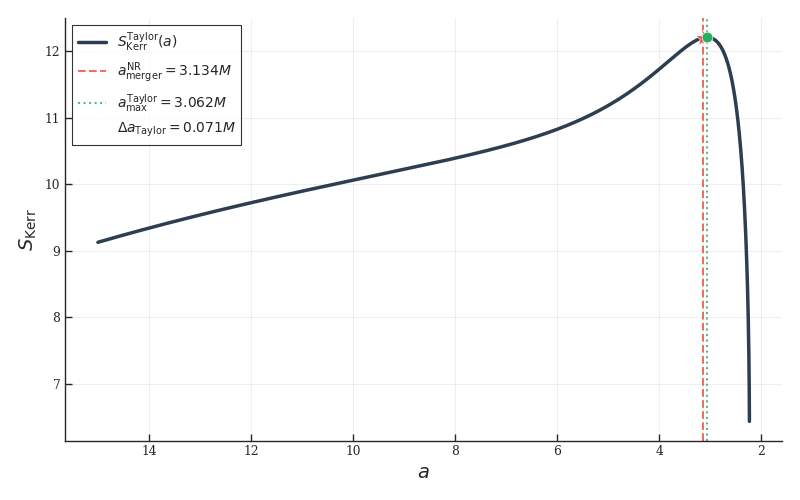

In [20]:
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

model_name = "Taylor degree 3"
a_taylor = taylor_curves_T[model_name]["a_extrap"]
ENT_taylor = taylor_curves_T[model_name]["ENT_extrap"]
a_max_taylor = results_taylor_df_T.loc[0, "a_max"]
S_max_taylor = results_taylor_df_T.loc[0, "S_max"]
delta_a_taylor = np.abs(a_max_taylor - a_merger)
sort_idx = np.argsort(a_taylor)
a_sorted = a_taylor[sort_idx]
ent_sorted = ENT_taylor[sort_idx]
valid_interp_mask = (np.isfinite(a_sorted)&np.isfinite(ent_sorted))
a_sorted_valid = a_sorted[valid_interp_mask]
ent_sorted_valid = ent_sorted[valid_interp_mask]
y_at_merger = np.interp(a_merger,a_sorted_valid,ent_sorted_valid)
y_at_max_taylor = np.interp(a_max_taylor,a_sorted_valid,ent_sorted_valid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(a_taylor,ENT_taylor,label=r"$S_{\rm Kerr}^{\rm Taylor}(a)$",color="#2c3e50",lw=2.5)
ax.scatter(a_merger,y_at_merger,marker="*",s=150,color="#e74c3c",zorder=5,edgecolor="white",linewidth=0.5)
ax.scatter(a_max_taylor,y_at_max_taylor,marker="o",s=60,color="#27ae60",zorder=5,edgecolor="white",linewidth=0.5)
ax.axvline(a_merger,color="#e74c3c",linestyle="--",lw=1.5,alpha=0.8,label=fr"$a_{{\rm merger}}^{{\rm NR}}={a_merger:.3f}M$")
ax.axvline(a_max_taylor,color="#27ae60",linestyle=":",lw=1.5,alpha=0.8,label=fr"$a_{{\max}}^{{\rm Taylor}}={a_max_taylor:.3f}M$")
ax.plot([],[]," ",label=fr"$\Delta a_{{\rm Taylor}}={delta_a_taylor:.3f}M$")
ax.invert_xaxis()
ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$S_{\rm Kerr}$")
ax.legend(frameon=True,shadow=False,fancybox=False,edgecolor="black",loc="best")
sns.despine()
plt.tight_layout()
plt.show()